In [5]:
import ddlpy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import timedelta

locations = ddlpy.locations()

roompot_buiten = locations.loc[
    (locations["Naam"] == "Oosterschelde Roompotsluis buiten") &
    (locations["Grootheid.Code"] == "WATHTE") &
    (locations["Compartiment.Code"] == "OW") &
    (locations["ProcesType"] == "meting")]

start = datetime.datetime(2025, 10, 22)
end = datetime.datetime(2025, 10, 25)

metingen = ddlpy.measurements(roompot_buiten.iloc[0], start, end)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  3.86it/s]


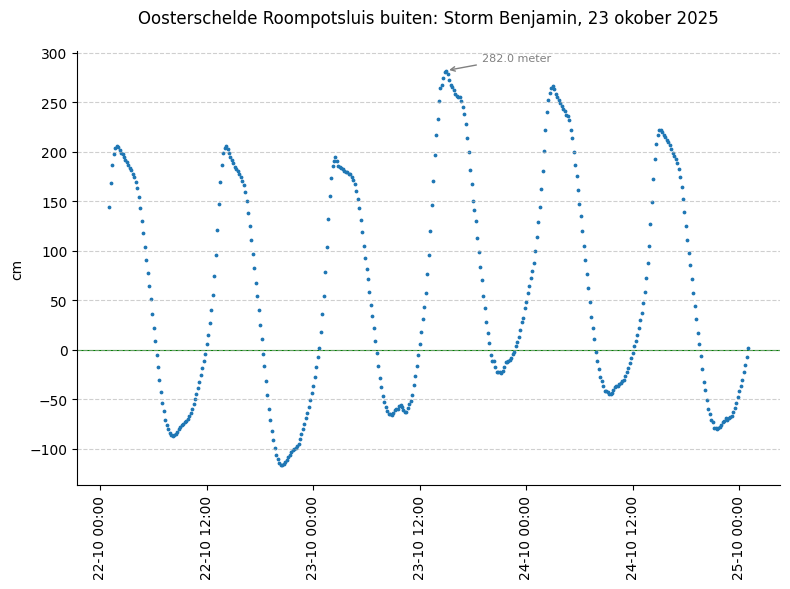

Hoogst gemeten watersstand boven NAP: 2.82 meter


In [6]:
metingen = metingen.reset_index()[["time","Meetwaarde.Waarde_Numeriek"]]
metingen["time"] = metingen["time"].dt.tz_localize(None)
metingen["time"] = pd.to_datetime(metingen["time"])


fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(metingen["time"], metingen["Meetwaarde.Waarde_Numeriek"], s=3, color="tab:blue", label="Meetwaarde", zorder=1)

ax.set_title("Oosterschelde Roompotsluis buiten: Storm Benjamin, 23 okober 2025", pad=20)
ax.tick_params(axis="x", rotation=90)
ax.set_ylabel("cm")
ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=2)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))
ax.axhline(0, color="green", linewidth=0.8, zorder=0)

max_idx = metingen["Meetwaarde.Waarde_Numeriek"].idxmax()
max_tijd = metingen["time"][max_idx]
max_waterstand = metingen["Meetwaarde.Waarde_Numeriek"][max_idx]

ax.annotate(text=f"{max_waterstand} meter",
            xy=(max_tijd, max_waterstand),
            xytext=(max_tijd + timedelta(hours=4), max_waterstand + 10),
            fontsize=8, color="grey",
            arrowprops=dict(arrowstyle="->", color="grey"))

ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

max_idx = metingen["Meetwaarde.Waarde_Numeriek"].idxmax()
max_waterstand = metingen["Meetwaarde.Waarde_Numeriek"][max_idx]/100
print(f"Hoogst gemeten watersstand boven NAP: {max_waterstand} meter")

In [7]:
namen = locations.loc[locations["Naam"] == "Oosterschelde Roompotsluis buiten"][["Naam","Compartiment.Code","Compartiment.Omschrijving", "ProcesType", "Grootheid.Code",
"Parameter_Wat_Omschrijving"]]
namen.head(3)

,Naam,Compartiment.Code,Compartiment.Omschrijving,ProcesType,Grootheid.Code,Parameter_Wat_Omschrijving
Code,,,,,,
oosterschelde.roompotsluis.buiten,Oosterschelde Roompotsluis buiten,OW,Oppervlaktewater,meting,50%_L,Percentielen per etmaal Levendigheid 50 percen...
oosterschelde.roompotsluis.buiten,Oosterschelde Roompotsluis buiten,OW,Oppervlaktewater,meting,70%_L,Percentielen per etmaal Levendigheid 70 percen...
oosterschelde.roompotsluis.buiten,Oosterschelde Roompotsluis buiten,OW,Oppervlaktewater,meting,80%_L,Percentielen per etmaal Levendigheid 80 percen...


In [8]:
locations.head(3)

,Locatie_MessageID,Lat,Lon,Coordinatenstelsel,Naam,Omschrijving,Parameter_Wat_Omschrijving,ProcesType,Compartiment.Code,Compartiment.Omschrijving,...,BioTaxon.Code,BioTaxon.Omschrijving,Orgaan.Code,Orgaan.Omschrijving,Groepering.Code,Groepering.Omschrijving,Typering.Code,Typering.Omschrijving,WaardeBewerkingsMethode.Code,WaardeBewerkingsMethode.Omschrijving
Code,,,,,,,,,,,,,,,,,,,,,
kornwerderzand.waddenzee.buitenhaven,129,53.074590,5.334757,ETRS89,Kornwerderzand Waddenzee buitenhaven,Kornwerderzand Waddenzee buitenhaven,Percentielen per etmaal Levendigheid 50 percen...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,LEVDHD5,Levendigheid,LEVDHD,Levendigheid,other:%24H,Percentielen per etmaal
zwolle.ijssel,144,52.508600,6.053000,ETRS89,"Zwolle, IJssel",voorheen Katerveer,Percentielen per etmaal Levendigheid 50 percen...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,LEVDHD5,Levendigheid,LEVDHD,Levendigheid,other:%24H,Percentielen per etmaal
lelystad.houtribsluis.zuid,683,52.526351,5.433916,ETRS89,"Lelystad, Houtribsluis, zuid","Lelystad, Houtribsluis, zuid",Percentielen per etmaal Levendigheid 50 percen...,meting,OW,Oppervlaktewater,...,NVT,NVT,NVT,NVT,LEVDHD5,Levendigheid,LEVDHD,Levendigheid,other:%24H,Percentielen per etmaal


In [9]:
stoffen = locations.loc[(locations["Naam"] == "Oosterschelde, 4") & (locations["Compartiment.Code"] == "OW") &
locations["Parameter_Wat_Omschrijving"].str.lower().str.contains("Saliniteit".lower())]

In [10]:
hammen = locations.loc[
    (locations["Naam"] == "Oosterschelde, 4") &
    (locations["Grootheid.Code"] == "CONCTTE") &
    (locations["ProcesType"] == "meting")]

start = datetime.datetime(2026, 5, 23)
end = datetime.datetime(2026, 5, 25)

metingen = ddlpy.measurements(hammen.iloc[0], start, end)

100%|█████████████████████████████████████████████| 1/1 [00:00<00:00,  3.07it/s]


In [11]:
metingen.index = metingen.index.tz_convert("Europe/Amsterdam")
saliniteit_280 = metingen.loc[metingen["WaarnemingMetadata.Bemonsteringshoogte"] == "-280"].copy()
saliniteit_880 = metingen.loc[metingen["WaarnemingMetadata.Bemonsteringshoogte"] == "-880"].copy()

saliniteit_280["Meetwaarde.Waarde_Numeriek"] = round(saliniteit_280["Meetwaarde.Waarde_Numeriek"] / 1000, 3)
saliniteit_880["Meetwaarde.Waarde_Numeriek"] = round(saliniteit_880["Meetwaarde.Waarde_Numeriek"] / 1000, 3)

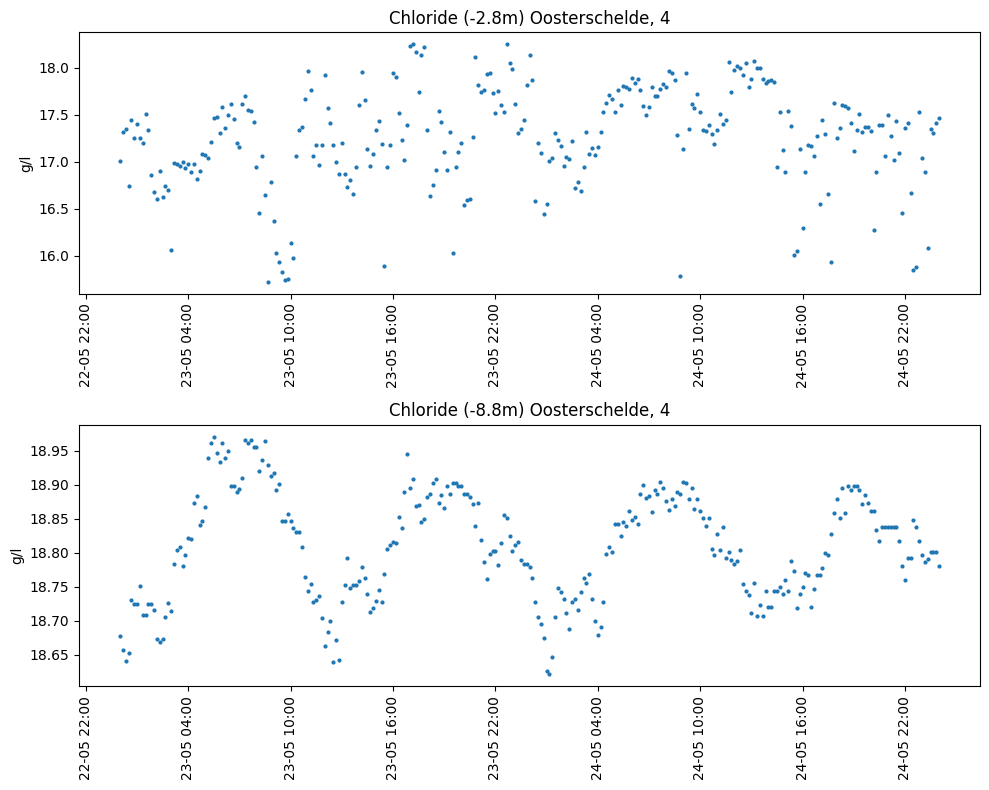

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(10,8))

ax[0].scatter(saliniteit_280.index, saliniteit_280["Meetwaarde.Waarde_Numeriek"], s=4)
ax[0].set_title("Chloride (-2.8m) Oosterschelde, 4")
ax[0].set_ylabel("g/l")
ax[0].tick_params(axis="x", rotation=90)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))

ax[1].scatter(saliniteit_880.index, saliniteit_880["Meetwaarde.Waarde_Numeriek"], s=4)
ax[1].set_title("Chloride (-8.8m) Oosterschelde, 4")
ax[1].set_ylabel("g/l")
ax[1].tick_params(axis="x", rotation=90)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%m %H:%M"))

plt.tight_layout()
plt.show()

In [13]:
stad = locations.loc[(locations["Compartiment.Code"] == "OW") & (locations["Naam"] == "Vlissingen")]

In [14]:
stad.groupby(["Naam", "Grootheid.Code", "Parameter_Wat_Omschrijving"]).size().reset_index().drop_duplicates()

,Naam,Grootheid.Code,Parameter_Wat_Omschrijving,0
0,Vlissingen,50%_L,Percentielen per etmaal Levendigheid 50 percen...,1
1,Vlissingen,70%_L,Percentielen per etmaal Levendigheid 70 percen...,1
2,Vlissingen,80%_L,Percentielen per etmaal Levendigheid 80 percen...,1
3,Vlissingen,90%_L,Percentielen per etmaal Levendigheid 90 percen...,1
4,Vlissingen,GETVVG,Getijvervroeging in Oppervlaktewater in min,1
5,Vlissingen,HOOGWTDG,Hoogwater dag in Oppervlaktewater t.o.v. Norma...,1
6,Vlissingen,LAAGWTDG,Laagwater dag in Oppervlaktewater t.o.v. Norma...,1
7,Vlissingen,NVT,Getijextreemtype astronomisch in Oppervlaktewater,1
8,Vlissingen,NVT,Getijextreemtype in Oppervlaktewater,3
9,Vlissingen,NVT,Levendigheid in Oppervlaktewater in cm2,1


In [15]:
# Bounding box van Zeeland (bij benadering)
zeeland = locations[
    (locations["Lat"] > 51.2) & (locations["Lat"] < 51.8) &
    (locations["Lon"] > 3.3) & (locations["Lon"] < 4.3) &
    (locations["Compartiment.Code"] == "OW") &
    (locations["Grootheid.Code"] == "CONCTTE")
]

zeeland_qgis = zeeland.loc[zeeland["Parameter_Wat_Omschrijving"].str.contains("kwik")].drop_duplicates()
#zeeland_qgis.to_csv("zeeland_qgis.csv", index=False)
data = zeeland_qgis["Grootheid.Code"].reset_index()
data

,Code,Grootheid.Code
0,stadaantharingvliet.drinkwaterinnnamepunt,CONCTTE
1,walcheren.2kmuitdekust,CONCTTE
2,sluis,CONCTTE
3,terneuzen.landtong,CONCTTE
4,zuidergat.boei44,CONCTTE
...,...,...
69,antwerpskanaalpand.km2,CONCTTE
70,terneuzen.goesekade,CONCTTE
71,zijpe,CONCTTE
72,lamswaarde.boei59,CONCTTE


In [17]:
import ddlpy
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from datetime import timedelta

#locations = ddlpy.locations()
#
#zeeland = locations[
#    (locations["Naam"] == "Vlissingen") &
#    (locations["Compartiment.Code"] == "OW") &
#    (locations["Grootheid.Code"] == "WATHTE") &
#    (locations["ProcesType"] == "meting") &
#    (locations["Groepering.Code"] == "GETETM2")
#]
#
#start = datetime.datetime(1900,1,1)
#end = datetime.datetime(2026,1,1)
#
#data = ddlpy.measurements(zeeland.iloc[0], start, end)

In [18]:
#data.to_csv("Vlissingen_temp.csv")

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pad = "Data/Vlissingen_temp.csv.zip"
df = pd.read_csv(pad)
df["time"] = pd.to_datetime(df["time"])
df["time"] = df["time"].dt.tz_convert("Europe/Amsterdam")
df.loc[df["time"].dt.year == 2019, "Meetwaarde.Waarde_Numeriek"]/=10

vlissingen = df.loc[
    (df["WaarnemingMetadata.OpdrachtgevendeInstantie"] == "RIKZMON_WAT") &
    (df["time"].dt.year.between(1900, 2024))].groupby(df["time"].dt.year)["Meetwaarde.Waarde_Numeriek"].mean().reset_index()

In [22]:
vlissingen.head(3)

,time,Meetwaarde.Waarde_Numeriek
0,1900,-14.790928
1,1901,-17.080794
2,1902,-19.043262


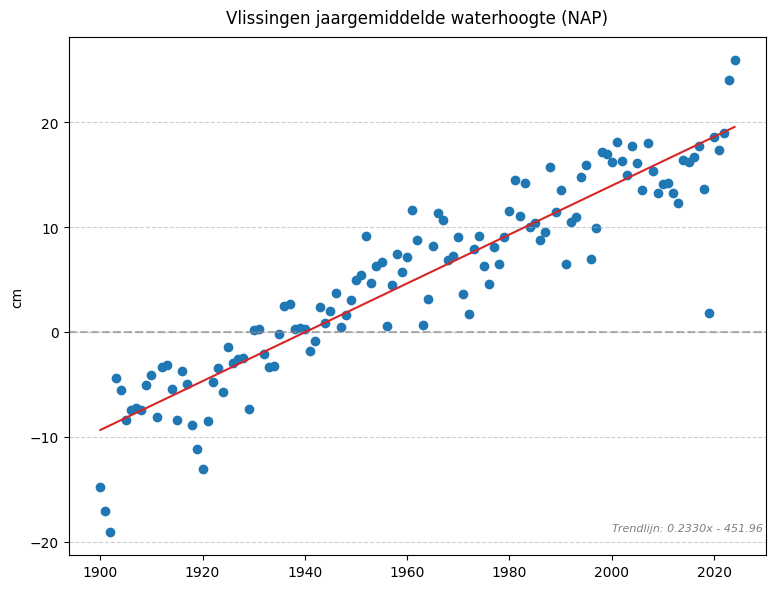

In [23]:
fig, ax = plt.subplots(figsize=(8,6))

coef = np.polyfit(vlissingen["time"], vlissingen["Meetwaarde.Waarde_Numeriek"], deg=1)
trend = np.poly1d(coef)
a, b = coef

ax.scatter(vlissingen["time"], vlissingen["Meetwaarde.Waarde_Numeriek"], color="tab:blue")
ax.plot(vlissingen["time"], trend(vlissingen["time"]), color="tab:red", zorder=4)

ax.set_title("Vlissingen jaargemiddelde waterhoogte (NAP)", pad=10, zorder=3)
ax.set_ylabel("cm")
ax.axhline(0, color="grey", linestyle="--", alpha=0.6)
ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=1)

ax.annotate(text=f"Trendlijn: {a:.4f}x - {abs(b):.2f}", xy=(2000, -19), color="grey", fontstyle="italic", fontsize=8)
plt.savefig("vlissingen.png", dpi=300)
plt.tight_layout()
plt.show()

### Berekening stijging zeespiegel meetstation Vlissingen tussen het jaar 1900 en 2024

<img src="Data/FullSizeRender.jpg" width="600">

In [24]:
# Filter to get matching rows, then select the first one
plaats = locations[
    (locations["Naam"] == "Vlissingen") &
    (locations["Compartiment.Code"] == "OW") &
    (locations["Grootheid.Code"] == "WATHTE") &
    (locations["ProcesType"] == "meting") &
    (locations["Groepering.Code"] == "GETETM2")
]
        
        

beschikbaar = ddlpy.measurements_amount(
    plaats.iloc[0],
    start_date="1900-01-01",
    end_date="2026-01-01"
)

beschikbaar

,AantalMetingen
Groeperingsperiode,
1900,1411
1901,1410
1902,1411
1903,1410
1904,1415
...,...
2021,1411
2022,1410
2023,1411


### Ontwikkeling zeespiegel.
* yoy met ruwe data gebruik: .diff()
* 10-jarig gemiddelde gebruik: rolling()
* verschil met het gemiddelde 1995-2014

In [25]:
vlissingen["yoy_change"] = vlissingen["Meetwaarde.Waarde_Numeriek"].diff()
vlissingen["yoy_smooth"] = vlissingen["yoy_change"].rolling(10, center=True).mean()

avg = vlissingen.loc[vlissingen["time"].between(1995, 2014)]["Meetwaarde.Waarde_Numeriek"].mean()
vlissingen["avg"] = vlissingen["Meetwaarde.Waarde_Numeriek"] - avg

In [26]:
vlissingen

,time,Meetwaarde.Waarde_Numeriek,yoy_change,yoy_smooth,avg
0,1900,-14.790928,NaN,NaN,-29.610098
1,1901,-17.080794,-2.289865,NaN,-31.899963
2,1902,-19.043262,-1.962469,NaN,-33.862432
3,1903,-4.344437,14.698826,NaN,-19.163606
4,1904,-5.562235,-1.217798,NaN,-20.381404
...,...,...,...,...,...
120,2020,18.614569,16.826262,0.950275,3.795399
121,2021,17.381290,-1.233279,NaN,2.562120
122,2022,18.980851,1.599561,NaN,4.161682
123,2023,24.006378,5.025527,NaN,9.187209


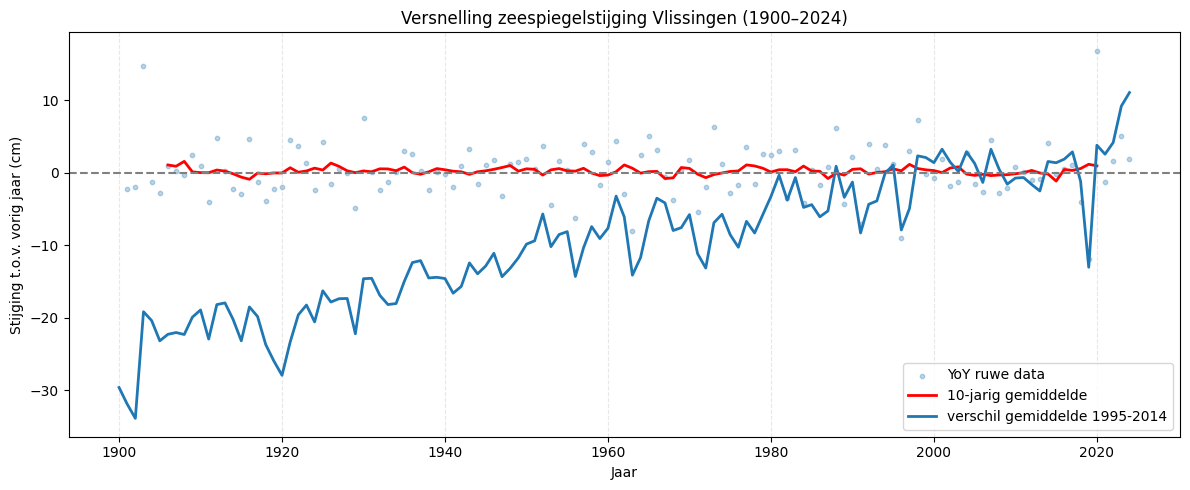

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.scatter(vlissingen["time"], vlissingen["yoy_change"], alpha=0.3, s=10, label="YoY ruwe data")
ax.plot(vlissingen["time"], vlissingen["yoy_smooth"], color="red", linewidth=2, label="10-jarig gemiddelde")
ax.plot(vlissingen["time"], vlissingen["avg"], color="tab:blue", linewidth=2, label="verschil gemiddelde 1995-2014")
ax.axhline(0, color="gray", linestyle="--")
ax.set_xlabel("Jaar")
ax.set_ylabel("Stijging t.o.v. vorig jaar (cm)")
ax.set_title("Versnelling zeespiegelstijging Vlissingen (1900–2024)")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend()
plt.savefig("vlis_versnelling.png")
plt.tight_layout()
plt.show()

In [72]:
vlissingen

,time,Meetwaarde.Waarde_Numeriek,yoy_change,yoy_smooth,avg
0,1900,-14.790928,NaN,NaN,-29.610098
1,1901,-17.080794,-2.289865,NaN,-31.899963
2,1902,-19.043262,-1.962469,NaN,-33.862432
3,1903,-4.344437,14.698826,NaN,-19.163606
4,1904,-5.562235,-1.217798,NaN,-20.381404
...,...,...,...,...,...
120,2020,18.614569,16.826262,0.950275,3.795399
121,2021,17.381290,-1.233279,NaN,2.562120
122,2022,18.980851,1.599561,NaN,4.161682
123,2023,24.006378,5.025527,NaN,9.187209


In [28]:
from scipy.stats import linregress

clean = vlissingen.dropna(subset=["yoy_change"])
slope, intercept, r, p, se = linregress(clean["time"], clean["yoy_change"])
print(f"Slope: {slope:.4f}/jaar,corr: {r:.2f},  p-waarde: {p:.4f}")

Slope: 0.0004/jaar,corr: 0.00,  p-waarde: 0.9708


## `linregress()` — uitleg variabelen

`scipy.stats.linregress` trekt de best passende rechte lijn door je data:
**y = slope × x + intercept**

De vijf returnwaarden vertellen je alles over die lijn en hoe goed die past.

---

#### `slope` — helling van de lijn
Hoeveel *y* verandert per eenheid *x*. In dit geval: hoeveel de jaarlijkse zeespiegelverandering toe- of afneemt per jaar. Resultaat: **0,0004** — vrijwel niks.

#### `intercept` — snijpunt met de y-as
De theoretische waarde bij x = 0. Bij deze data zou dat de voorspelde YoY-verandering in het jaar 0 zijn, wat natuurlijk onzinnig is. Puur wiskundig nodig om de lijn te definiëren, maar inhoudelijk niet interessant.

#### `r` — correlatiecoëfficiënt
Een getal tussen −1 en +1 dat aangeeft hoe sterk het lineaire verband is. Dicht bij 0 = geen verband (zoals hier), dicht bij 1 of −1 = sterk verband. De variant *r²* (r-kwadraat) vertelt welk percentage van de variatie door de lijn verklaard wordt.

#### `p` — p-waarde
Beantwoordt de vraag: *"Hoe waarschijnlijk is het dat ik deze slope zou vinden als er in werkelijkheid géén verband is?"* Resultaat: **0,97** — dat betekent 97% kans dat toeval dit verklaart. Volstrekt niet significant. Onder 0,05 wordt het pas interessant.

#### `se` — standaardfout van de slope
De onzekerheidsmarge: hoe precies is de slope bepaald? Een grote `se` ten opzichte van de slope betekent dat de helling niet betrouwbaar vastgesteld kan worden — wat past bij dit resultaat.

---

> **Conclusie:** Er is geen statistisch aantoonbare versnelling of vertraging in de zeespiegelstijging bij Vlissingen.

In [29]:
slope, intercept, r, p, se = linregress(vlissingen["time"], vlissingen["avg"])
print(f"Slope: {slope:.4f}/jaar,corr: {r:.2f},  p-waarde: {p:.4f}")

Slope: 0.2330/jaar,corr: 0.93,  p-waarde: 0.0000
